In [1]:
import torch
import matplotlib.pyplot as plt 
import numpy as np
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader
import torch.nn as nn 

In [2]:
# from model import NeuralNetwork
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.l1 = nn.Linear(784, 100)
        self.l2 = nn.Linear(100,50)
        self.l3 = nn.Linear(50,10)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    def forward(self,x):
        x = self.l1(x)
        h_pre_l1 = x.clone()
        x = self.relu(x)
        h_post_l1 = x.clone()
        x = self.l2(x)
        h_pre_l2 = x.clone()
        x = self.relu(x)
        h_post_l2 = x.clone()
        x = self.l3(x)

        return x, h_pre_l1, h_post_l1, h_pre_l2, h_post_l2

In [3]:
model = NeuralNetwork()

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [5]:
train_dataset = datasets.MNIST(root='Experiments/Exp-1/dataset', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='Experiments/Exp-1/dataset', train=False, transform=transform, download=True)

In [6]:
BATCH_SIZE = 64 
LR = 0.001  
NUM_EPOCHs = 10

In [7]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
loss_function = nn.CrossEntropyLoss()

In [9]:
single_batch = iter(train_loader)
inputs, labels = next(single_batch)
# print(inputs.shape, labels.shape)
print(inputs[0].shape)
example = inputs[0].view(1,28*28)
print(example.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


In [ ]:
inputs = inputs.view(inputs.size(0), 28*28)   

outputs,h_pre_l1, h_post_l1, h_pre_l2, h_post_l2 = model(inputs)
loss = loss_function(outputs, labels)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(loss.item())

2.292443037033081


In [ ]:
import torch
import matplotlib.pyplot as plt

def compute_covariance(H):
    H = H - H.mean(dim=0, keepdim=True)
    return (H.T @ H) / H.size(0)

def stable_rank_from_H(H):
    C = compute_covariance(H)
    trace_C = torch.trace(C)
    trace_C2 = torch.trace(C @ C)
    return (trace_C**2 / (trace_C2 + 1e-12)).item()

def log_pseudo_determinant(W):
    S = torch.linalg.svdvals(W)
    return torch.sum(torch.log(S + 1e-12)).item()

def condition_number(W):
    S = torch.linalg.svdvals(W)
    return (S.max() / (S.min() + 1e-12)).item()

def gradient_alignment(W):
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    u1 = U[:, 0]
    v1 = Vh[0, :]
    principal = torch.outer(u1, v1)

    G = W.grad

    g_vec = G.reshape(-1)
    p_vec = principal.reshape(-1)

    return (torch.dot(g_vec, p_vec) /
           (torch.norm(g_vec)*torch.norm(p_vec) + 1e-12)).item()


In [ ]:
# # Layer 1
# C_pre_l1  = compute_covariance(h_pre_l1)
# C_post_l1 = compute_covariance(h_post_l1)

# rank_pre_l1  = stable_rank_from_H(C_pre_l1)
# rank_post_l1 = stable_rank_from_H(C_post_l1)

# # Layer 2
# C_pre_l2  = compute_covariance(h_pre_l2)
# C_post_l2 = compute_covariance(h_post_l2)

# rank_pre_l2  = stable_rank_from_H(C_pre_l2)
# rank_post_l2 = stable_rank_from_H(C_post_l2)

# print("Layer 1 Pre-ReLU Stable Rank :", rank_pre_l1.item())
# print("Layer 1 Post-ReLU Stable Rank:", rank_post_l1.item())

# print("Layer 2 Pre-ReLU Stable Rank :", rank_pre_l2.item())
# print("Layer 2 Post-ReLU Stable Rank:", rank_post_l2.item())


In [ ]:
pdet_l1 = log_pseudo_determinant(model.l1.weight)
pdet_l2 = log_pseudo_determinant(model.l2.weight)

print("Layer 1 pseudo-det:", pdet_l1)
print("Layer 2 pseudo-det:", pdet_l2)

Layer 1 pseudo-det: -58.03789520263672
Layer 2 pseudo-det: -35.91167449951172


In [ ]:
def gradient_alignment(W):
    # SVD
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    
    u1 = U[:, 0]           # (d_out,)
    v1 = Vh[0, :]          # (d_in,)
    
    # Principal matrix direction
    principal = torch.outer(u1, v1)   # (d_out, d_in)
    
    G = W.grad
    
    # Flatten
    g_vec = G.reshape(-1)
    p_vec = principal.reshape(-1)
    
    cos_sim = torch.dot(g_vec, p_vec) / (
        torch.norm(g_vec) * torch.norm(p_vec) + 1e-12
    )
    
    return cos_sim.item()

In [ ]:
def condition_number(W):
    S = torch.linalg.svdvals(W)
    
    sigma_max = S.max()
    sigma_min = S.min()
    
    return (sigma_max / (sigma_min + 1e-12)).item()

In [ ]:
align_l1 = gradient_alignment(model.l1.weight)
align_l2 = gradient_alignment(model.l2.weight)

print("Grad alignment L1:", align_l1)
print("Grad alignment L2:", align_l2)


Grad alignment L1: -0.0009894149843603373
Grad alignment L2: -0.006282503250986338


In [ ]:
kappa_l1 = condition_number(model.l1.weight)
kappa_l2 = condition_number(model.l2.weight)

print("Condition number L1:", kappa_l1)
print("Condition number L2:", kappa_l2)

Condition number L1: 2.0501224994659424
Condition number L2: 5.812541961669922


In [ ]:
history = {
    "loss": [],
    "rank_l1_pre": [],
    "rank_l1_post": [],
    "rank_l2_pre": [],
    "rank_l2_post": [],
    "logdet_l1": [],
    "logdet_l2": [],
    "kappa_l1": [],
    "kappa_l2": [],
    "align_l1": [],
    "align_l2": [],
    "test_loss":[],
    "test_acc": [],
}

In [ ]:
ref_inputs, ref_labels = next(iter(train_loader)) 
ref_inputs = ref_inputs.view(ref_inputs.size(0), -1)
for epoch in range(NUM_EPOCHs):
    model.train()
    total_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.view(inputs.size(0), -1)

        outputs, h_pre_l1, h_post_l1, h_pre_l2, h_post_l2 = model(inputs)
        loss = loss_function(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        # ---- Metrics that need gradients ----
        align_l1 = gradient_alignment(model.l1.weight)
        align_l2 = gradient_alignment(model.l2.weight)

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history["loss"].append(avg_loss)

    # ---- Test metrics (loss + accuracy) ----
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.view(inputs.size(0), -1)

            outputs, *_ = model(inputs)
            loss = loss_function(outputs, labels)
            test_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_test_loss = test_loss / len(test_loader)
    test_acc = correct / total

    history["test_loss"].append(avg_test_loss)
    history["test_acc"].append(test_acc)

    # ---- Geometry measured on fixed batch ----
    with torch.no_grad():
        _, h_pre_l1, h_post_l1, h_pre_l2, h_post_l2 = model(ref_inputs)

        history["rank_l1_pre"].append(stable_rank_from_H(h_pre_l1))
        history["rank_l1_post"].append(stable_rank_from_H(h_post_l1))
        history["rank_l2_pre"].append(stable_rank_from_H(h_pre_l2))
        history["rank_l2_post"].append(stable_rank_from_H(h_post_l2))

        history["logdet_l1"].append(log_pseudo_determinant(model.l1.weight))
        history["logdet_l2"].append(log_pseudo_determinant(model.l2.weight))
    
        history["kappa_l1"].append(condition_number(model.l1.weight))
        history["kappa_l2"].append(condition_number(model.l2.weight))

        history["align_l1"].append(align_l1)
        history["align_l2"].append(align_l2)

    print(f"Epoch {epoch+1}/{NUM_EPOCHs} | Loss: {avg_loss:.4f} | "
          f"Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.4f}")


Epoch 1/10 | Loss: 2.1677 | Test Loss: 1.9601 | Test Acc: 0.5583
Epoch 2/10 | Loss: 1.6175 | Test Loss: 1.2259 | Test Acc: 0.7257
Epoch 3/10 | Loss: 0.9881 | Test Loss: 0.7786 | Test Acc: 0.8066
Epoch 4/10 | Loss: 0.7009 | Test Loss: 0.5995 | Test Acc: 0.8456
Epoch 5/10 | Loss: 0.5706 | Test Loss: 0.5062 | Test Acc: 0.8678
Epoch 6/10 | Loss: 0.4960 | Test Loss: 0.4473 | Test Acc: 0.8806
Epoch 7/10 | Loss: 0.4467 | Test Loss: 0.4077 | Test Acc: 0.8895
Epoch 8/10 | Loss: 0.4122 | Test Loss: 0.3790 | Test Acc: 0.8971
Epoch 9/10 | Loss: 0.3865 | Test Loss: 0.3577 | Test Acc: 0.9011
Epoch 10/10 | Loss: 0.3669 | Test Loss: 0.3415 | Test Acc: 0.9028


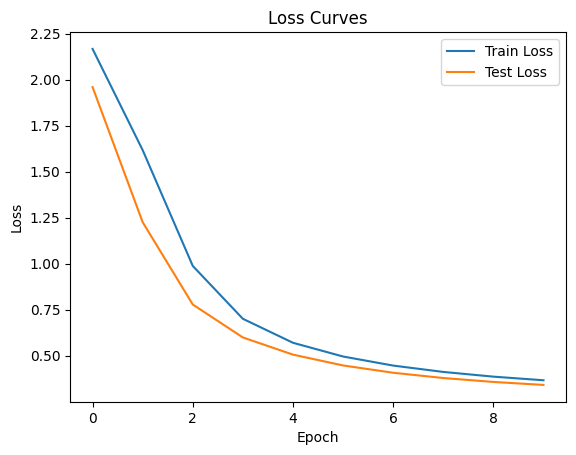

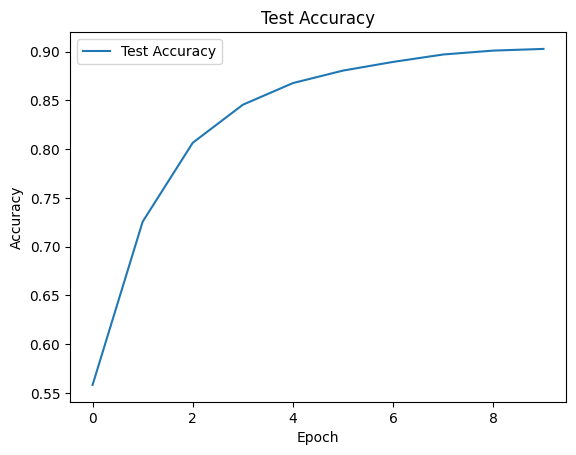

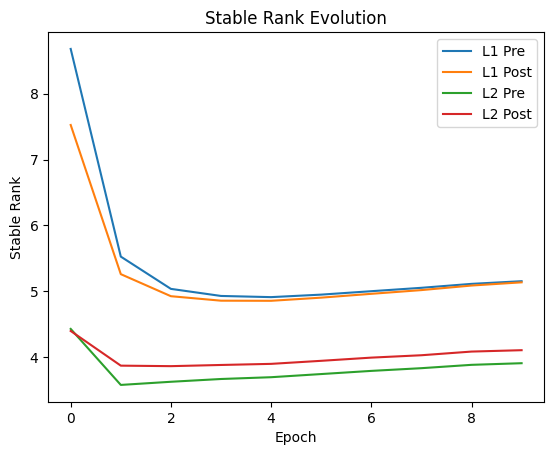

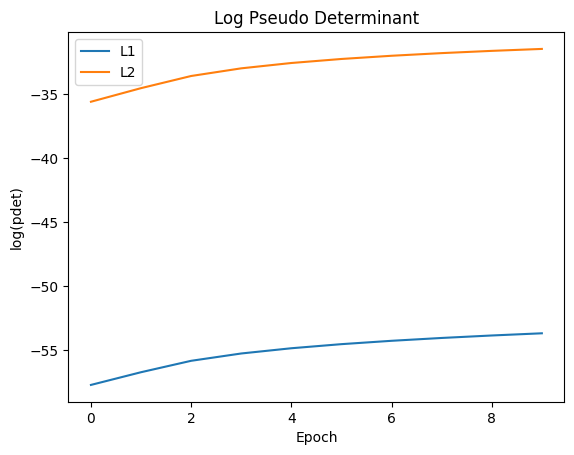

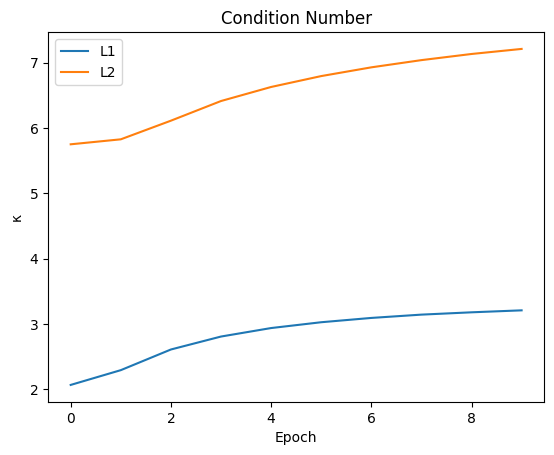

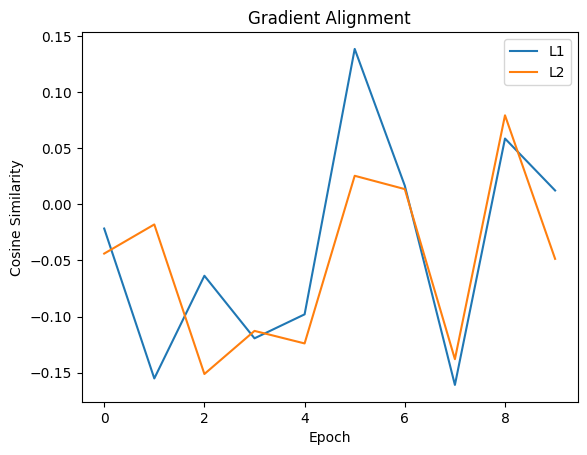

In [ ]:
# Training Loss
plt.figure()
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Test Accuracy
plt.figure()
plt.plot(history["test_acc"], label="Test Accuracy")
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Stable Rank
plt.figure()
plt.plot(history["rank_l1_pre"], label="L1 Pre")
plt.plot(history["rank_l1_post"], label="L1 Post")
plt.plot(history["rank_l2_pre"], label="L2 Pre")
plt.plot(history["rank_l2_post"], label="L2 Post")
plt.title("Stable Rank Evolution")
plt.xlabel("Epoch")
plt.ylabel("Stable Rank")
plt.legend()
plt.show()

# Log Pseudo Determinant
plt.figure()
plt.plot(history["logdet_l1"], label="L1")
plt.plot(history["logdet_l2"], label="L2")
plt.title("Log Pseudo Determinant")
plt.xlabel("Epoch")
plt.ylabel("log(pdet)")
plt.legend()
plt.show()

# Condition Number
plt.figure()
plt.plot(history["kappa_l1"], label="L1")
plt.plot(history["kappa_l2"], label="L2")
plt.title("Condition Number")
plt.xlabel("Epoch")
plt.ylabel("κ")
plt.legend()
plt.show()

# Gradient Alignment
plt.figure()
plt.plot(history["align_l1"], label="L1")
plt.plot(history["align_l2"], label="L2")
plt.title("Gradient Alignment")
plt.xlabel("Epoch")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.show()


In [8]:
# PATH = './weights/model.pt'
# torch.save(model.state_dict(), PATH)
single_batch = iter(test_dataset)
inputs = next(single_batch)

NameError: name 'test_dataset' is not defined